In [2]:
from sklearn.datasets import  fetch_california_housing
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor,AdaBoostRegressor, GradientBoostingRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [31]:
dfk = pd.read_csv("data/king_ country_ houses_aa.csv")

2. Explore the data to understand its structure — features, target variable, shape, and data types.
3. Clean the dataset (handle duplicates, missing values, etc.).
4. Split the dataset into features (X) and target (y).

In [ ]:
#dfkX = dfk[dfk.columns.drop('date')]

<Axes: xlabel='price', ylabel='Count'>

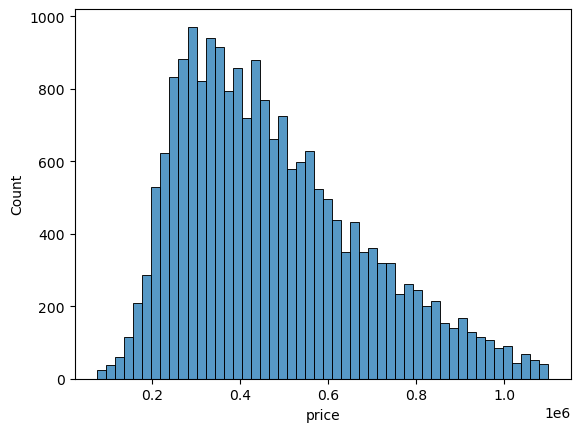

In [20]:
sns.histplot(data=dfk.price[dfk.price < 1100000])

In [19]:
dfk[dfk.price < 1100000].price.count()

np.int64(20394)

count     18611.000000
mean     433212.698082
std      160818.419764
min       75000.000000
25%      305000.000000
50%      415000.000000
75%      550000.000000
max      799990.000000
Name: price, dtype: float64   [dfk.price < 800000]

In [63]:
IQR = dfk.price.quantile(0.75) - dfk.price.quantile(0.25)
lower_bound = dfk.price.quantile(0.25) - 1.5 * IQR
upper_bound = dfk.price.quantile(0.75) + 1.5 * IQR
outliers = dfk[(dfk.price < lower_bound) | (dfk.price > upper_bound)]
outliers.size

25212

25k outliers on normal price data

<Axes: xlabel='count', ylabel='Count'>

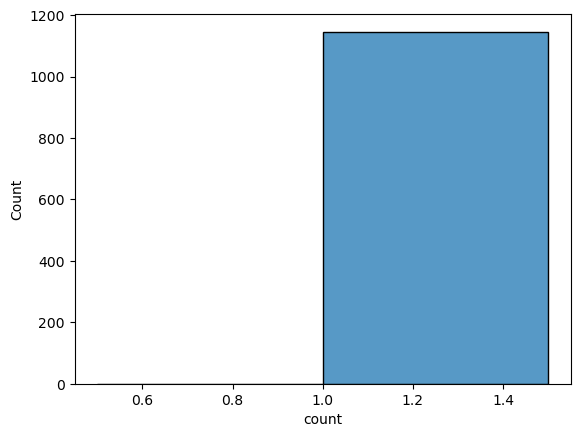

In [61]:
sns.histplot(outliers.value_counts(), bins=2)

In [10]:
#feature selection:
dfk.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

because of low correlation I think about dropping 'sqft_lot', 'condition', 'yr_renovated', 'long', 'sqft_lot15'

In [44]:


#dfkD = dfk.drop(columns=['sqft_lot', 'condition', 'yr_renovated', 'long', 'sqft_lot15']) # next time: inplace=True
#dfkD["date_2"] = pd.to_datetime(dfkD.date,format='%Y%m%dT000000')
#dfkD = dfkD[dfkD.columns.drop('date_2')]
dfkD = dfk
dfkD = dfkD[dfkD.columns.drop('date')]
dfkD

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,360000.0,3,2.50,1530,1131,3.0,0,0,3,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,400000.0,4,2.50,2310,5813,2.0,0,0,3,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,402101.0,2,0.75,1020,1350,2.0,0,0,3,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,400000.0,3,2.50,1600,2388,2.0,0,0,3,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [ ]:
sns.pairplot(dfkD, diag_kind='kde')

In [53]:
# coordinates of Seattle Downtown ca. (47.6062, -122.3321)
def haversine_distance(lat1, lon1, lat2=47.6062, lon2=-122.3321):
    r = 6371 # Erdradius in km
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)
    a = np.sin(delta_phi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(delta_lambda/2)**2
    return r * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

dfkD['dist_to_seattle'] = haversine_distance(dfk['lat'], dfk['long'])

### no effect on model s effectiveness

In [ ]:
#price is right skwed, so an attempt is
import numpy as np
dfkD['log_price']=np.log1p(dfkD['price'])
#dfkD.drop('price', inplace=True)



In [46]:
dfkD = dfkD[dfkD.columns.drop('price')]

In [64]:
IQR = dfkD.log_price.quantile(0.75) - dfkD.log_price.quantile(0.25)
lower_bound = dfkD.log_price.quantile(0.25) - 1.5 * IQR
upper_bound = dfkD.log_price.quantile(0.75) + 1.5 * IQR
outliers = dfkD[(dfkD.log_price < lower_bound) | (dfkD.log_price > upper_bound)]
outliers.size

6993

even with log(price) there are around 7k outliers...

In [ ]:
#suspicious no of rooms... when I take them out -> test performance decreases slightly
dfk3 = dfkD[dfkD['bedrooms'] < 33]
dfk2 = dfk3[dfk3['bedrooms'] > 0]
dfkD1 = dfk2[dfk2['bathrooms'] > 0]

In [78]:
y = dfkD1.log_price
X = dfkD1[dfkD1.columns.drop('log_price')]


#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
train_X, test_X, train_y, test_y = train_test_split(X, y, 
                                                    test_size = 0.25, 
                                                    random_state = 42)

XGBoost builds one tree for each class and the trees for each class are called a “group” of trees, so output dimension may change due to used model. Internally, XGBoost attempts to extract the categories from the dataframe inputs. For inference (predict), the re-coding happens on the fly and there’s no data copy.

In [83]:
#xGBoostRegressor
import xgboost as xgb

xgb_reg = xgb.XGBRegressor()
xgb_reg.fit(train_X, train_y)

y_pred = xgb_reg.predict(train_X)

print("#" * 23 + "XGBRegressor")
print("#" * 23 + "Train" + "#" * 23 )
trmse = mean_squared_error(train_y, y_pred)** (1 / 2)
train_mae = mean_absolute_error(train_y, y_pred)
tr2 = r2_score(train_y, y_pred)


print(f"Root Mean Squared Error: {trmse:.2f}") 
print('Mean Absolute Error    : {:.2f}'.format(train_mae))
print(f"R-squared Score       : {tr2:.2f}")

print("#" * 23 + "Test"  + "#" * 23 )
y_pred = xgb_reg.predict(test_X)
rmse = mean_squared_error(test_y, y_pred)** (1 / 2)
test_mae = mean_absolute_error(test_y, y_pred)
r2 = r2_score(test_y, y_pred)
print(f"Root Mean Squared Error: {rmse:.2f}") 
print('Mean Absolute Error    : {:.2f}'.format(test_mae))
print(f"R-squared Score        : {r2:.2f}")
print(f"R² Score    diff       : {tr2-r2:.3f}")

#######################XGBRegressor
#######################Train#######################
Root Mean Squared Error: 0.11
Mean Absolute Error    : 0.08
R-squared Score       : 0.96
#######################Test#######################
Root Mean Squared Error: 0.17
Mean Absolute Error    : 0.12
R-squared Score        : 0.89
R² Score    diff       : 0.068
